In [1]:
import os
import math
from pathlib import Path
from PIL import Image, UnidentifiedImageError
Image.MAX_IMAGE_PIXELS = None  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm, trange
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as T
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchvision.models import efficientnet_v2_l, EfficientNet_V2_L_Weights
from torchvision.models import regnet_y_16gf, RegNet_Y_16GF_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision.models import swin_v2_b, Swin_V2_B_Weights


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# CONFIG
# INPUT_SIZE = 300 #efficientnet
INPUT_SIZE = 384 

# BATCH_SIZE = 16
BATCH_SIZE = 8
NUM_EPOCHS = 20
ALPHA = 0.5
BETA = 0.5
EARLY_STOP_PATIENCE = 5
DROPOUT_RATE = 0.2
NUM_WORKERS = 2

In [3]:
# TRANSFORMS
train_transform = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5,
        # interpolation=T.InterpolationMode.BILINEAR
        interpolation=T.InterpolationMode.BICUBIC #vit, swin, regnet128gf
    ),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.RandomHorizontalFlip(p=0.5),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_test_transform = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

In [4]:
# DATASET
class WildfireDataset(Dataset):
    """
    Dataset cho Method 2 với 2 outputs:
    - Binary label: fire (0) vs nofire (1)
    - Multi-class label: 5 subclasses (0-4)
    """
    SUBCLASS_MAP = {
        'Both_smoke_and_fire': 0,
        'Smoke_from_fires': 1,
        'Fire_confounding_elements': 2,
        'Forested_areas_without_confounding_elements': 3,
        'Smoke_confounding_elements': 4
    }

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self._load_samples()
        print(f"\nLoaded {len(self.samples)} images from {root_dir}")
        self._print_class_distribution()

    def _load_samples(self):
        for class_name in ['fire', 'nofire']:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                print(f"Warning: {class_dir} not found!")
                continue
            binary_label = 0 if class_name == 'fire' else 1

            for subclass_dir in class_dir.iterdir():
                if not subclass_dir.is_dir():
                    continue
                subclass_name = subclass_dir.name
                if subclass_name not in self.SUBCLASS_MAP:
                    print(f"Unknown subclass '{subclass_name}' — skipping")
                    continue
                multiclass_label = self.SUBCLASS_MAP[subclass_name]

                image_paths = list(subclass_dir.glob('*'))
                valid_images = [
                    img for img in image_paths
                    if img.suffix.lower() in ['.jpg', '.jpeg', '.png']
                ]
                for img_path in valid_images:
                    self.samples.append({
                        'path': img_path,
                        'binary_label': binary_label,
                        'multiclass_label': multiclass_label,
                        'subclass_name': subclass_name
                    })

    def _print_class_distribution(self):
        total = len(self.samples)
        if total == 0:
            print("No samples found!")
            return

        binary_counts = {0: 0, 1: 0}
        multi_counts = {i: 0 for i in range(5)}
        for sample in self.samples:
            binary_counts[sample['binary_label']] += 1
            multi_counts[sample['multiclass_label']] += 1

        print("\nBinary Class Distribution:")
        print(f"  Fire:   {binary_counts[0]:>5} ({binary_counts[0]/total*100:>5.1f}%)")
        print(f"  NoFire: {binary_counts[1]:>5} ({binary_counts[1]/total*100:>5.1f}%)")
        print("\nMulti-Class Distribution:")
        for name, idx in self.SUBCLASS_MAP.items():
            count = multi_counts[idx]
            print(f"  [{idx}] {name:<50}: {count:>5} ({count/total*100:>5.1f}%)")

    def get_class_counts(self):
        binary_counts = torch.zeros(2, dtype=torch.long)
        multi_counts = torch.zeros(5, dtype=torch.long)
        for sample in self.samples:
            binary_counts[sample['binary_label']] += 1
            multi_counts[sample['multiclass_label']] += 1
        return binary_counts, multi_counts

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')
        except (UnidentifiedImageError, OSError) as e:
            # Skip corrupted image by returning next index (safe fallback)
            alt_idx = (idx + 1) % len(self)
            return self.__getitem__(alt_idx)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'binary_label': torch.tensor(sample['binary_label'], dtype=torch.long),
            'multiclass_label': torch.tensor(sample['multiclass_label'], dtype=torch.long)
        }

In [5]:
# LOAD DATASETS & DATALOADERS
DATASET_PATH = Path('/kaggle/input/chayrung-multiclass/the_wildfire_dataset/the_wildfire_dataset')

train_dataset = WildfireDataset(
    root_dir=DATASET_PATH / 'train',
    transform=train_transform
)

val_dataset = WildfireDataset(
    root_dir=DATASET_PATH / 'val',
    transform=val_test_transform
)

test_dataset = WildfireDataset(
    root_dir=DATASET_PATH / 'test',
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f"\nDataLoaders Created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")



Loaded 1887 images from /kaggle/input/chayrung-multiclass/the_wildfire_dataset/the_wildfire_dataset/train

Binary Class Distribution:
  Fire:     730 ( 38.7%)
  NoFire:  1157 ( 61.3%)

Multi-Class Distribution:
  [0] Both_smoke_and_fire                               :   269 ( 14.3%)
  [1] Smoke_from_fires                                  :   461 ( 24.4%)
  [2] Fire_confounding_elements                         :   236 ( 12.5%)
  [3] Forested_areas_without_confounding_elements       :   591 ( 31.3%)
  [4] Smoke_confounding_elements                        :   330 ( 17.5%)

Loaded 402 images from /kaggle/input/chayrung-multiclass/the_wildfire_dataset/the_wildfire_dataset/val

Binary Class Distribution:
  Fire:     156 ( 38.8%)
  NoFire:   246 ( 61.2%)

Multi-Class Distribution:
  [0] Both_smoke_and_fire                               :    57 ( 14.2%)
  [1] Smoke_from_fires                                  :    99 ( 24.6%)
  [2] Fire_confounding_elements                         :    50 ( 12

In [6]:
# COMPUTE CLASS WEIGHTS
def compute_class_weights(counts: torch.Tensor):
    """Compute inverse-frequency normalized weights (float tensor)."""
    counts = counts.float()
    # Avoid division by zero
    counts = torch.where(counts == 0, torch.ones_like(counts), counts)
    total = counts.sum()
    weights = total / (len(counts) * counts)
    return weights

binary_counts, multi_counts = train_dataset.get_class_counts()
binary_weights = compute_class_weights(binary_counts)
multi_weights = compute_class_weights(multi_counts)

# Move weights to device for criterion
binary_weights = binary_weights.to(device)
multi_weights = multi_weights.to(device)

print("\nBinary weights:", binary_weights)
print("Multi weights:", multi_weights)


Binary weights: tensor([1.2925, 0.8155], device='cuda:0')
Multi weights: tensor([1.4030, 0.8187, 1.5992, 0.6386, 1.1436], device='cuda:0')


In [ ]:
# MODEL
class MultiClassWildfireModel(nn.Module):
    def __init__(self, num_multi=5, backbone="regnet", pretrained=True, dropout_rate=0.3):
        super().__init__()

        self.backbone_name = backbone.lower()
            
        # RESNET
        if self.backbone_name == "effnet":
            weights = EfficientNet_V2_L_Weights.IMAGENET1K_V1 if pretrained else None
            self.base = efficientnet_v2_l(weights=weights)

            in_features = self.base.classifier[1].in_features
            self.base.classifier = nn.Identity()

        # REGNET
        elif self.backbone_name == "regnet":
            weights = RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1 if pretrained else None
            self.base = regnet_y_16gf(weights=weights)

            in_features = self.base.fc.in_features
            self.base.fc = nn.Identity()

        # VIT
        elif self.backbone_name == "vit":
            weights = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1 if pretrained else None
            self.base = vit_b_16(weights=weights)

            in_features = self.base.heads.head.in_features
            self.base.heads.head = nn.Identity()

        # SWIN
        elif self.backbone_name == "swin":
            weights = Swin_V2_B_Weights.IMAGENET1K_V1 if pretrained else None
            self.base = swin_v2_b(weights=weights)

            in_features = self.base.head.in_features
            self.base.head = nn.Identity()

        else:
            raise ValueError("wrong name")

        # FC CHUNG
        self.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)
        )

        self.multi = nn.Linear(256, num_multi)

    def forward(self, x):
        x = self.base(x)
        x = self.fc(x)
        return self.multi(x)


# model = MultiClassWildfireModel(pretrained=True, dropout_rate=0.2).to(device)
model = MultiClassWildfireModel(pretrained=True, backbone="swin", dropout_rate=0.2).to(device)

# Optionally unfreeze backbone (recommended for fine-tuning)
for param in model.base.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(f"\nModel: EfficientNet with MTL")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Input size: {INPUT_SIZE}x{INPUT_SIZE}")

Downloading: "https://download.pytorch.org/models/swin_v2_b-781e5279.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_b-781e5279.pth
100%|██████████| 336M/336M [00:01<00:00, 210MB/s]


  Total parameters:     87,169,533
  Trainable parameters: 87,169,533
  Input size: 384x384


In [ ]:
# TRAINING SETUP
# criterion_multiclass = nn.CrossEntropyLoss(weight=multi_weights)
criterion_multiclass = nn.CrossEntropyLoss()


optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

# Early stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\nConfiguration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Optimizer: AdamW (weight_decay=0.01)")
print(f"  Loss weights: α={ALPHA}, β={BETA}")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")


Configuration:
  Epochs: 20
  Batch size: 8
  Optimizer: AdamW (weight_decay=0.01)
  Loss weights: α=0.5, β=0.5
  Early stopping patience: 5


In [9]:
def train_one_epoch_multiclass(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_all, labels_all = [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['multiclass_label'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds_all.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    acc = accuracy_score(labels_all, preds_all)
    return {'loss': epoch_loss, 'multi_acc': acc}

@torch.no_grad()
def validate_multiclass(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all, labels_all = [], []

    for batch in tqdm(dataloader, desc='Validation', leave=False):
        images = batch['image'].to(device)
        labels = batch['multiclass_label'].to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        preds_all.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    acc = accuracy_score(labels_all, preds_all)
    return {'loss': epoch_loss, 'multi_acc': acc}


In [10]:
# MAIN TRAINING LOOP WITH EARLY STOP COUNT
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60 + "\n")

history = {'train_loss': [], 'val_loss': [], 'train_multi_acc': [], 'val_multi_acc': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
early_stop_count = 0  

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_metrics = train_one_epoch_multiclass(model, train_loader, criterion_multiclass, optimizer, device)
    val_metrics = validate_multiclass(model, val_loader, criterion_multiclass, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_multi_acc'].append(train_metrics['multi_acc'])
    history['val_multi_acc'].append(val_metrics['multi_acc'])

    print(f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['multi_acc']:.4f}")
    print(f"Val   Loss={val_metrics['loss']:.4f}, Val   Acc={val_metrics['multi_acc']:.4f}")

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_state, 'best_multiclass_model_state.pth')
        print(f"New best model saved (Val Loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"Patience counter: {patience_counter}/{EARLY_STOP_PATIENCE}")
        if patience_counter >= EARLY_STOP_PATIENCE:
            early_stop_count += 1
            print("Early stopping triggered")
            break

# After training
print(f"\nNumber of times early stopping would have triggered: {early_stop_count}")


STARTING TRAINING


Epoch 1/20


Train Loss=1.2482, Train Acc=0.4992
Val   Loss=0.7889, Val   Acc=0.7488
New best model saved (Val Loss=0.7889)

Epoch 2/20


Train Loss=0.6854, Train Acc=0.7440
Val   Loss=0.5023, Val   Acc=0.8259
New best model saved (Val Loss=0.5023)

Epoch 3/20


Train Loss=0.4816, Train Acc=0.8357
Val   Loss=0.5109, Val   Acc=0.8483
Patience counter: 1/5

Epoch 4/20


Train Loss=0.3829, Train Acc=0.8680
Val   Loss=0.5014, Val   Acc=0.8308
New best model saved (Val Loss=0.5014)

Epoch 5/20


...

Train Loss=0.2554, Train Acc=0.9179
Val   Loss=0.5757, Val   Acc=0.8483
Patience counter: 1/5

Epoch 8/20


Train Loss=0.2382, Train Acc=0.9242
Val   Loss=0.5113, Val   Acc=0.8607
Patience counter: 2/5

Epoch 9/20


Train Loss=0.1941, Train Acc=0.9412
Val   Loss=0.5055, Val   Acc=0.8756
Patience counter: 3/5

Epoch 10/20


Train Loss=0.1778, Train Acc=0.9417
Val   Loss=0.5559, Val   Acc=0.8632
Patience counter: 4/5

Epoch 11/20


Train Loss=0.1496, Train Acc=0.9544
Val   Loss=0.5719, Val   Acc=0.8582
Patience counter: 5/5
Early stopping triggered

Number of times early stopping would have triggered: 1


In [11]:
if best_model_state is not None:
    # load best onto model
    model.load_state_dict(best_model_state)
    model.to(device)
    print("Loaded best model for final test evaluation.")

Loaded best model for final test evaluation.


In [ ]:
# TEST EVALUATION 
print("\n" + "="*60)
print("FINAL TEST EVALUATION")
print("="*60 + "\n")

# Test
test_metrics = validate_multiclass(model, test_loader, criterion_multiclass, device)
print(f"Test Loss={test_metrics['loss']:.4f}, Test Multi-class Acc={test_metrics['multi_acc']:.4f}")

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(device)
        labels = batch['multiclass_label'].to('cpu').numpy()
        outputs = model(images)
        preds = outputs.argmax(dim=1).to('cpu').numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

# class_names = [
#     'Both_smoke_and_fire', 'Smoke_from_fires', 'Fire_confounding_elements',
#     'Forested_areas_without_confounding_elements', 'Smoke_confounding_elements'
# ]


FINAL TEST EVALUATION



Test Loss=0.3132, Test Multi-class Acc=0.8951


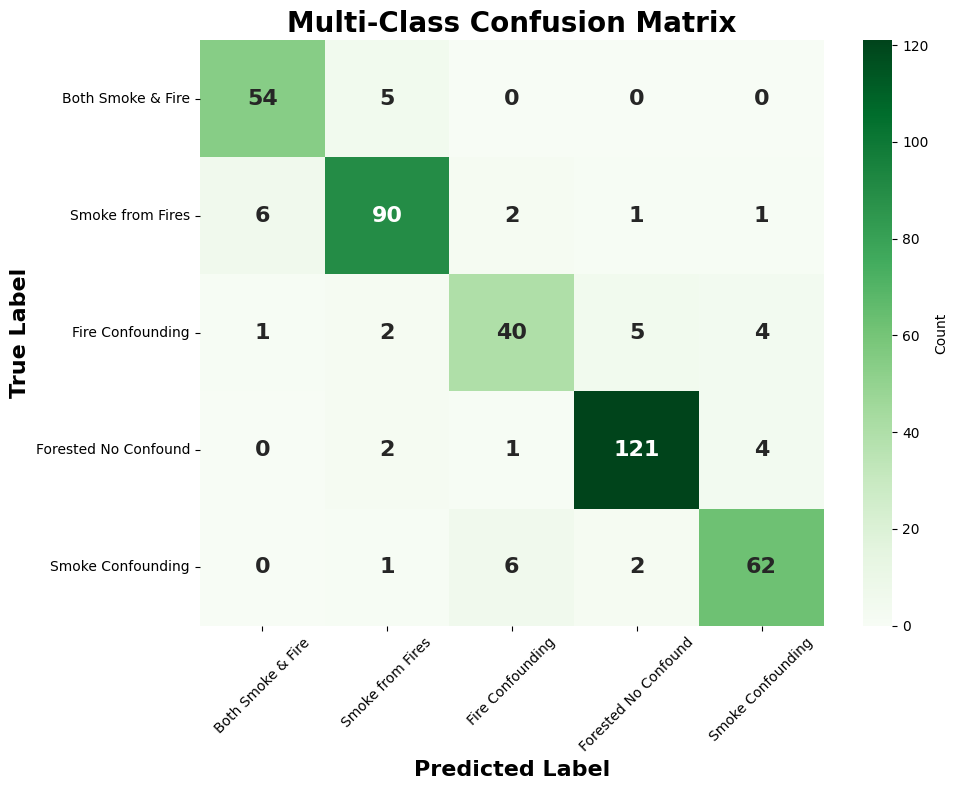

In [13]:
class_names = [
    'Both Smoke & Fire',          # Both_smoke_and_fire
    'Smoke from Fires',           # Smoke_from_fires
    'Fire Confounding',           # Fire_confounding_elements
    'Forested No Confound',       # Forested_areas_without_confounding_elements
    'Smoke Confounding'           # Smoke_confounding_elements
]

# --- compute confusion matrix ---
cm_multi = confusion_matrix(all_labels, all_preds)

# --- figure lớn hơn ---
plt.figure(figsize=(10, 8))  # tăng kích thước figure
sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names[:cm_multi.shape[1]],
    yticklabels=class_names[:cm_multi.shape[0]],
    cbar_kws={'label': 'Count'},
    annot_kws={'fontsize': 16, 'fontweight': 'bold'}  # tăng font size
)

plt.title('Multi-Class Confusion Matrix', fontsize=20, fontweight='bold')
plt.ylabel('True Label', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=16, fontweight='bold')

plt.xticks(rotation=45)  # xoay chữ cho dễ đọc
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_large.png', dpi=200, bbox_inches='tight')
plt.show()


PLOTTING TRAINING HISTORY
Saved training history plot to 'training_history_multiclass.png'


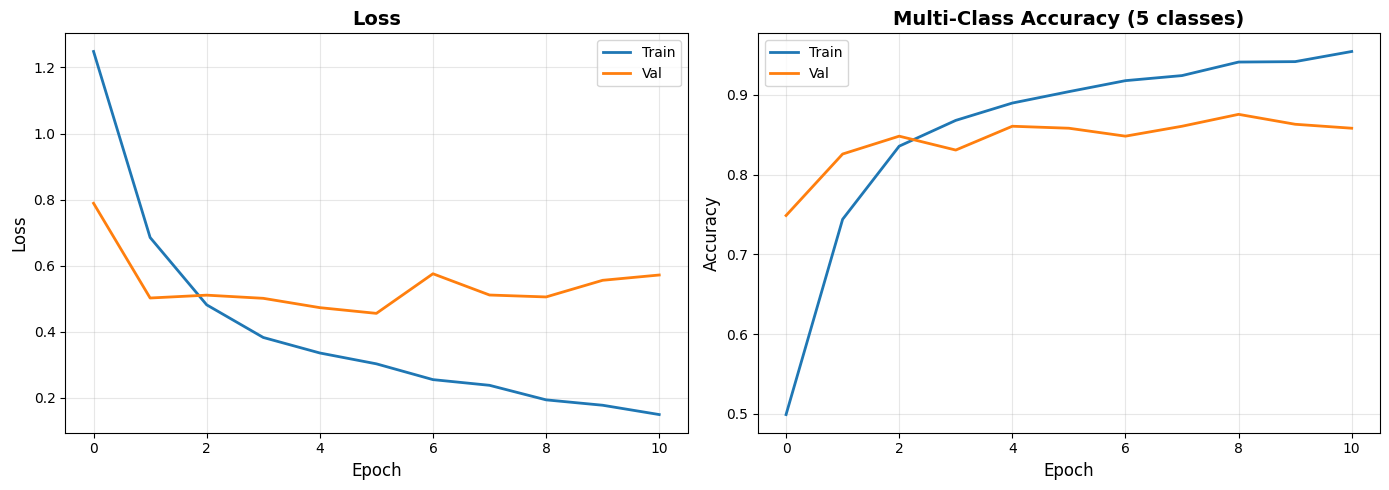

In [14]:
print("\n" + "="*60)
print("PLOTTING TRAINING HISTORY")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Multi-class Accuracy
axes[1].plot(history['train_multi_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_multi_acc'], label='Val', linewidth=2)
axes[1].set_title('Multi-Class Accuracy (5 classes)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_multiclass.png', dpi=150, bbox_inches='tight')
print("Saved training history plot to 'training_history_multiclass.png'")
plt.show()

In [15]:
print("\n" + "="*60)
print("SAVING MODEL & RESULTS")
print("="*60)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'test_metrics': test_metrics,
    'confusion_matrix': cm_multi.tolist(),
    'config': {
        'input_size': INPUT_SIZE,
        'num_epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': 1e-5,
        'architecture': 'EfficientNet',
        'total_params': total_params,
        'trainable_params': trainable_params
    }
}

torch.save(checkpoint, 'multiclass_wildfire_model.pth')
print("Model checkpoint saved to 'multiclass_wildfire_model.pth'")

# Save metrics CSV
metrics_df = pd.DataFrame({
    'epoch': list(range(1, len(history['train_loss']) + 1)),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_multi_acc': history['train_multi_acc'],
    'val_multi_acc': history['val_multi_acc']
})
metrics_df.to_csv('training_metrics_multiclass.csv', index=False)
print("Training metrics saved to 'training_metrics_multiclass.csv'")

test_results = pd.DataFrame([test_metrics])
test_results.to_csv('test_results_multiclass.csv', index=False)
print("Test results saved to 'test_results_multiclass.csv'")

print("\n" + "="*60)
print("ALL DONE!")
print("="*60)
print("\nGenerated files:")
print("  1. best_multiclass_model_state.pth - Best model state")
print("  2. multiclass_wildfire_model.pth  - Full checkpoint")
print("  3. training_history_multiclass.png - Training curves")
print("  4. confusion_matrix.png            - Confusion matrix")
print("  5. training_metrics_multiclass.csv - Metrics per epoch")
print("  6. test_results_multiclass.csv     - Final test results")


SAVING MODEL & RESULTS
Model checkpoint saved to 'multiclass_wildfire_model.pth'
Training metrics saved to 'training_metrics_multiclass.csv'
Test results saved to 'test_results_multiclass.csv'

ALL DONE!

Generated files:
  1. best_multiclass_model_state.pth - Best model state
  2. multiclass_wildfire_model.pth  - Full checkpoint
  3. training_history_multiclass.png - Training curves
  4. confusion_matrix.png            - Confusion matrix
  5. training_metrics_multiclass.csv - Metrics per epoch
  6. test_results_multiclass.csv     - Final test results
